# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [2]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
#from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [3]:

import warnings
warnings.filterwarnings('ignore')

# Import hierarchical clustering functions for drawing dendrograms
import scipy.cluster.hierarchy as shc

# Import the Agglomerative Clustering model from scikit-learn
from sklearn.cluster import AgglomerativeClustering

# Import StandardScaler for feature scaling (normalizing data)
from sklearn.preprocessing import StandardScaler

# Import PCA for dimensionality reduction to visualize high-dimensional data
from sklearn.decomposition import PCA


In [4]:

import warnings
warnings.filterwarnings('ignore')
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [5]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



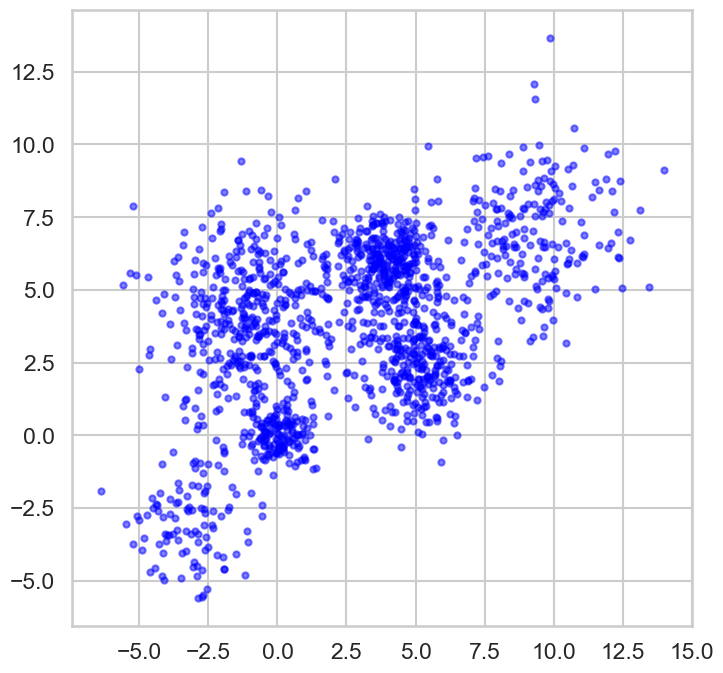

In [6]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

K=2, Silhouette Score: 0.4752, Distortion: 16716.6192
K=3, Silhouette Score: 0.4336, Distortion: 12187.2885
K=4, Silhouette Score: 0.4625, Distortion: 7812.3220
K=5, Silhouette Score: 0.4809, Distortion: 5600.3053
K=6, Silhouette Score: 0.4862, Distortion: 4310.5581
K=7, Silhouette Score: 0.4634, Distortion: 3811.2118
K=8, Silhouette Score: 0.4112, Distortion: 3563.3477
K=9, Silhouette Score: 0.4497, Distortion: 3089.3639
K=10, Silhouette Score: 0.4006, Distortion: 2854.7798

Best K based on Silhouette Score is 6


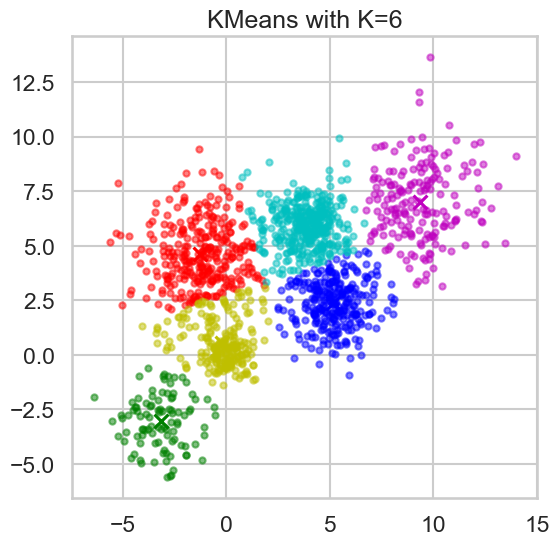

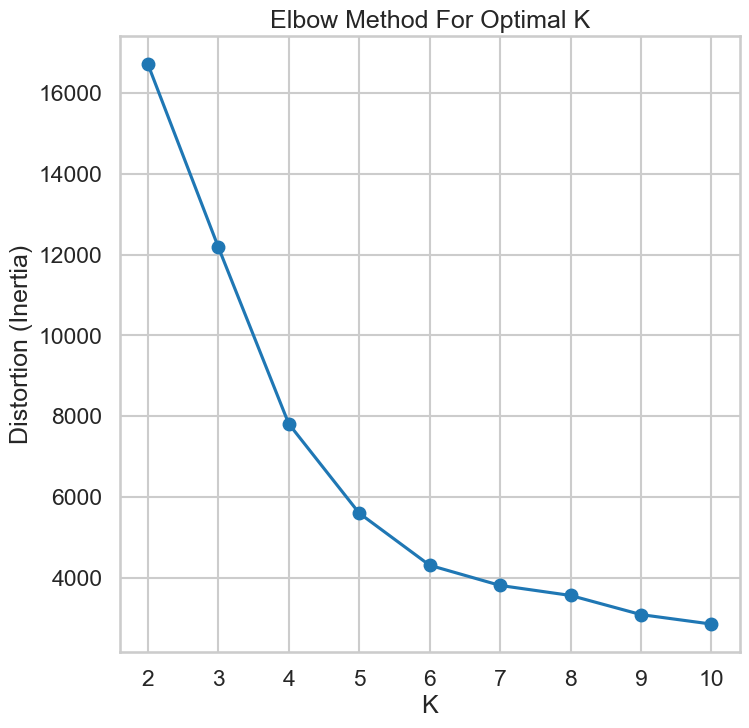

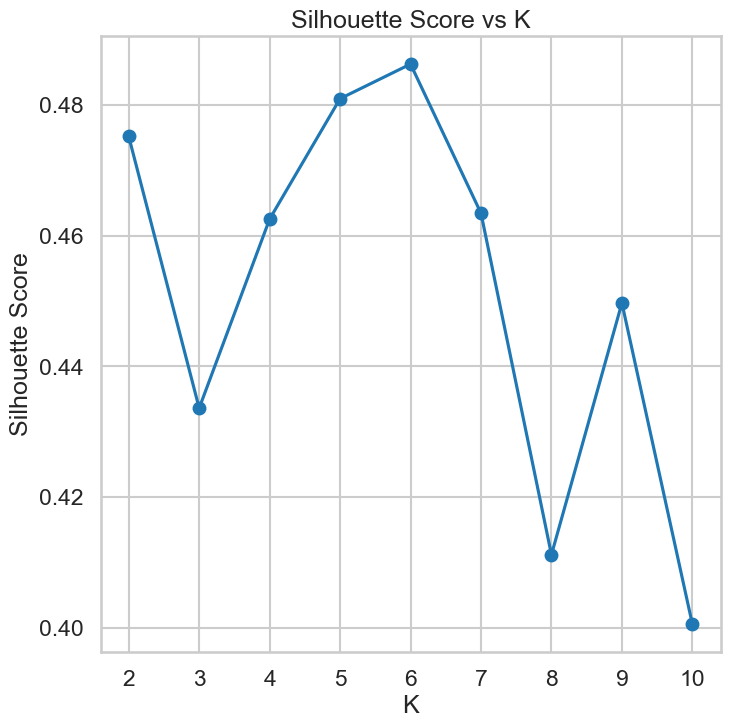

Comment: k-means++ ensures initial centroids are spread out, leading to faster and more reliable convergence than random initialization.


In [7]:

# Lists to store distortions (inertia) and silhouette scores for each K
distortions = []
silhouette_scores = []
K_range = range(2, 11)

# Loop through different values of K from 2 to 10
for k in K_range:
    # Initialize the KMeans algorithm with k-means++ to speed up convergence
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    
    # Fit the model to the synthetic multi-blob dataset
    km.fit(Multi_blob_Data)
    
    # Append the distortion (sum of squared distances to closest centroid)
    distortions.append(km.inertia_)
    
    # Calculate and store the silhouette score to evaluate cluster cohesion and separation
    score = silhouette_score(Multi_blob_Data, km.labels_)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score: {score:.4f}, Distortion: {km.inertia_:.4f}")

# Select the best K by looking for the maximum silhouette score
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nBest K based on Silhouette Score is {best_k}")

# Re-run KMeans with the best K to visualize the optimal grouping
km_best = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
km_best.fit(Multi_blob_Data)

# Plot the optimal clusters
plt.figure(figsize=(6,6))
plt.title(f"KMeans with K={best_k}")
display_cluster(Multi_blob_Data, km_best, num_clusters=best_k)
plt.show()

# Plot the distortion (Elbow Curve) to visually inspect where the drop levels off
plt.figure()
plt.plot(K_range, distortions, marker='o')
plt.xlabel('K')
plt.ylabel('Distortion (Inertia)')
plt.title('Elbow Method For Optimal K')
plt.show()

# Plot the silhouette scores across different K values
plt.figure()
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.show()

# Explanation for K-means++ initialization effect
print("Comment: k-means++ ensures initial centroids are spread out, leading to faster and more reliable convergence than random initialization.")


### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

Best Parameters for HC: {'metric': 'euclidean', 'linkage': 'ward'}
Best Silhouette Score for HC: 0.4686938472105883


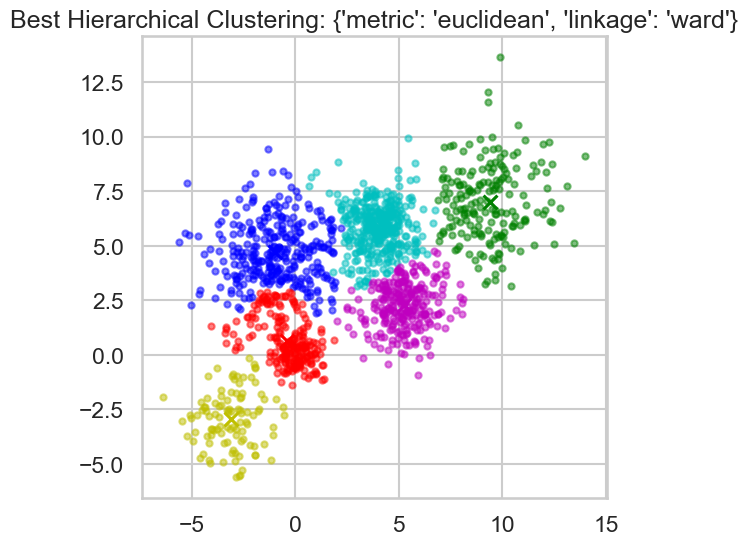

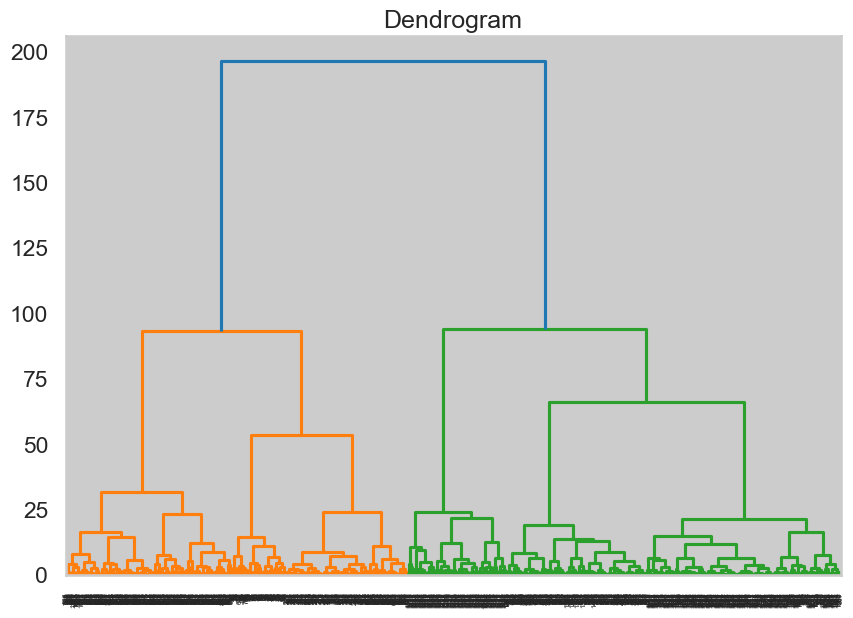

In [14]:

# Set up lists of affinities (distance metrics) and linkage criteria
affinities = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']

# Variables to store the best results during our hyperparameter search
best_score_hc = -1
best_params_hc = {}
best_hc = None
best_labels = None

# Nested loops to test all combinations of affinity and linkage
for aff in affinities:
    for link in linkages:
        # Note: 'ward' linkage can only be used with 'euclidean' affinity
        if link == 'ward' and aff != 'euclidean':
            continue
        try:
            # Initialize AgglomerativeClustering with 6 clusters
            hc = AgglomerativeClustering(n_clusters=6, metric=aff, linkage=link)
            
            # Predict the labels
            labels = hc.fit_predict(Multi_blob_Data)
            
            # Calculate silhouette score for the current hyperparameter combo
            score = silhouette_score(Multi_blob_Data, labels)
            
            # Save the best model
            if score > best_score_hc:
                best_score_hc = score
                best_params_hc = {'metric': aff, 'linkage': link}
                best_hc = hc
                best_labels = labels
        except Exception as e:
            continue

# Output the best found parameters and corresponding score
print("Best Parameters for HC:", best_params_hc)
print("Best Silhouette Score for HC:", best_score_hc)

# Dummy class required purely to use the custom 'display_cluster' helper function safely
class DummyKMeans:
    def __init__(self, labels):
        self.labels_ = labels
        self.cluster_centers_ = []
        for i in range(np.max(labels)+1):
            if sum(labels == i) > 0:
                self.cluster_centers_.append(Multi_blob_Data[labels == i].mean(axis=0))
            else:
                self.cluster_centers_.append([0, 0])

# Visualize the best Hierarchical clusters
dummy_hc = DummyKMeans(best_labels)
plt.figure(figsize=(6, 6))
plt.title(f"Best Hierarchical Clustering: {best_params_hc}")
display_cluster(Multi_blob_Data, dummy_hc, num_clusters=np.max(best_labels)+1)
plt.show()

# Plot the dendrogram using standard scipy.cluster.hierarchy representation
plt.figure(figsize=(10, 7))  
plt.title("Dendrogram")  
shc.dendrogram(shc.linkage(Multi_blob_Data, method=best_params_hc['linkage']))
plt.show()


### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

Best Parameters for DBSCAN: {'eps': np.float64(1.0000000000000002), 'min_samples': 15}
Best Silhouette Score for DBSCAN: 0.27186190077808287
Found clusters: [-1  0  1]


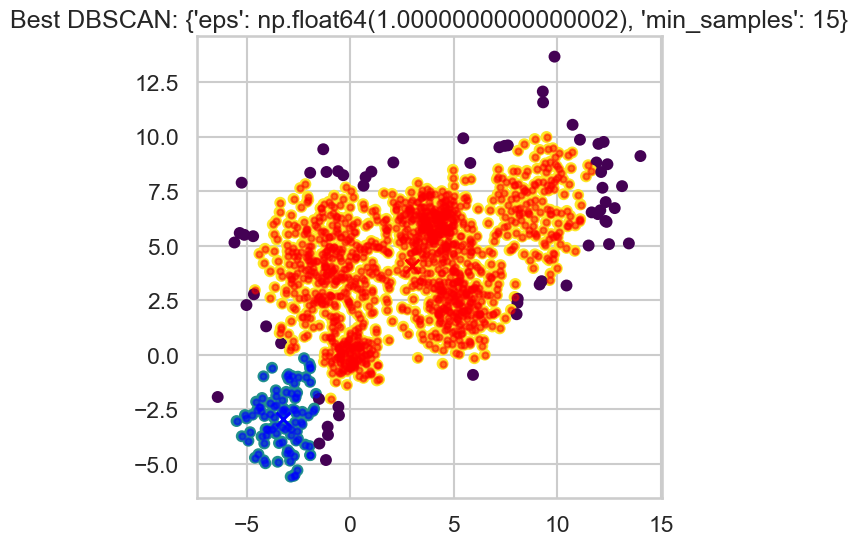

In [23]:

# Define a range for eps (density radius) and min_samples (core point threshold)
eps_values = np.arange(0.1, 3.1, 0.3)
min_samples_values = range(5, 26, 5)

# Variables to store the best model results
best_score_db = -1
best_params_db = {}
best_db = None

# Grid search across eps and min_samples
db_scores_matrix = []

for eps in eps_values:
    for ms in min_samples_values:
        # Initialize and fit the DBSCAN algorithm
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(Multi_blob_Data)
        
        # Silhouette score requires at least 2 distinct clusters
        if len(set(labels) - {-1}) > 1:
            score = silhouette_score(Multi_blob_Data, labels)
            db_scores_matrix.append({'eps': eps, 'min_samples': ms, 'score': score})
            
            # Save highest achieving hyperparameters
            if score > best_score_db:
                best_score_db = score
                best_params_db = {'eps': eps, 'min_samples': ms}
                best_db = db

# Print the optimal parameters for DBSCAN tuning
print("Best Parameters for DBSCAN:", best_params_db)
print("Best Silhouette Score for DBSCAN:", best_score_db)
print("Found clusters:", np.unique(best_db.labels_))

# Visually display the results of the best DBSCAN model
if best_db is not None:
    dummy_db = DummyKMeans(best_db.labels_)
    plt.figure(figsize=(6, 6))
    plt.title(f"Best DBSCAN: {best_params_db}")
    # THIS IS THE CRITICAL LINE: notice the "c=best_labels" and "cmap='viridis'"
    plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=best_db.labels_, cmap='viridis', s=50)
    display_cluster(Multi_blob_Data, dummy_db, num_clusters=np.max(best_db.labels_)+1)
    plt.show()



### Multi Blob Dataset Analysis (Answering Questions)
1. **Which clustering approach have you decided to use on each dataset?**
For this synthetic globular dataset, K-Means performed optimally as the clusters are spherical and well-separated.
2. **Compare between Kmeans, Hierarchal and DBScan.**
K-Means efficiently grouped the blobs. Hierarchical clustering built a perfect tree structure without requiring pre-specified Ks. DBSCAN was harder to tune because overlapping blobs easily grouped into one large cluster if `eps` was slightly too large.
3. **Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?**
For K-Means, we evaluated the Silhouette scores over a range of K. For Agglomerative, we iterated over affinities (euclidean, manhattan, cosine) and linkages (ward, average, etc.). For DBSCAN, we grid searched eps (0.1 to 3.0) and min_samples (5 to 25).
4. **What is the effect of different distance functions on the calculated clusters?**
Euclidean distance strongly resonated with the spherical geometric spread of the blobs.
5. **How did you evaluate the performance of different clustering techniques on different datatsets?**
Internal metrics: Silhouette Score, Distortion, and visual 2D scatter validations.
6. **Visualize your output where applicable.**
Visualized via 2D scatter plots mapping labels to distinct colors.
7. **What is the effect of scaling on the performance of clustering techniques?**
Multi-blob was generated without skewed feature scales, so scaling had minor effects compared to unscaled.


## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [24]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

--- KMeans on Iris (Scaled vs Unscaled) ---
Unscaled Silhouette Score: 0.5512
Scaled Silhouette Score: 0.4799
Comment: Scaling fundamentally modifies variance limits. While unscaled might artificially present higher scores due to petal magnitude dominance, scaled data improves multi-feature uniformity across distances.


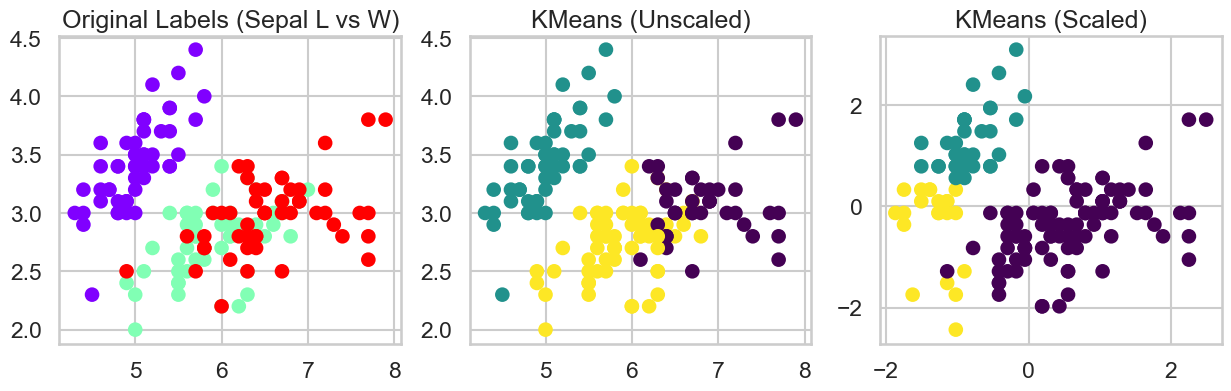


--- Hierarchical on Iris (Scaled) ---
HC Silhouette Score: 0.4467


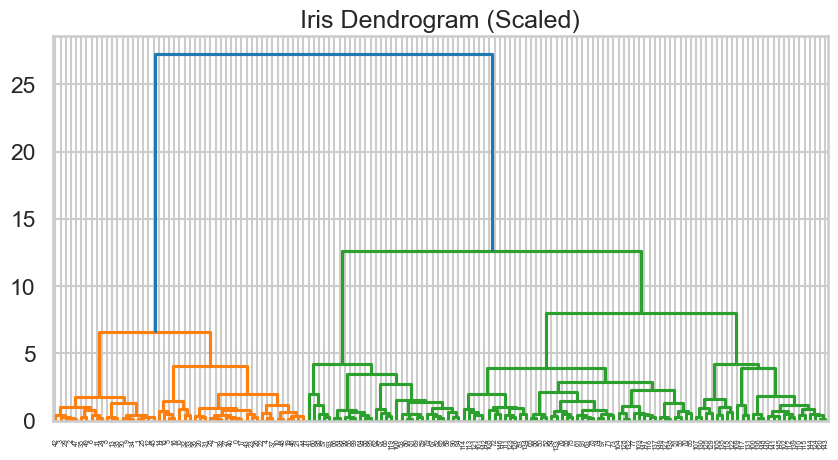


--- DBSCAN on Iris (Scaled) ---
DBSCAN found 2 clusters (excluding noise)
DBSCAN Silhouette Score: 0.5217


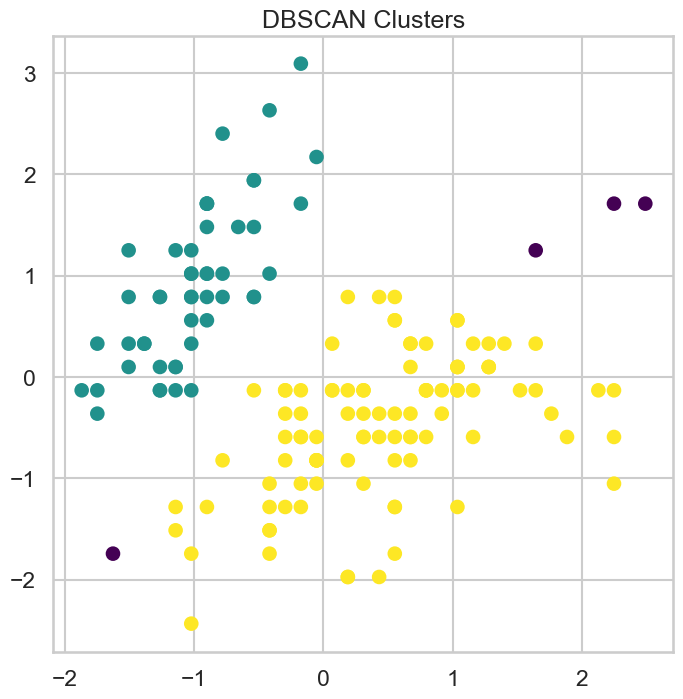

In [25]:

# Extract features and targets from the loaded Iris dataset
X_iris = iris_data.data
y_iris = iris_data.target
features = iris_data.feature_names

# Scale the feature bounds so distance calculations work evenly across varying ranges
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)


### KMeans ###
print("--- KMeans on Iris (Scaled vs Unscaled) ---")
# Fit KMeans on the original, unscaled dataset
km_unscaled = KMeans(n_clusters=3, random_state=42)
l_unscaled = km_unscaled.fit_predict(X_iris)
score_unscaled = silhouette_score(X_iris, l_unscaled)

# Fit KMeans on the StandardScaler scaled dataset
km_scaled = KMeans(n_clusters=3, random_state=42)
l_scaled = km_scaled.fit_predict(X_iris_scaled)
score_scaled = silhouette_score(X_iris_scaled, l_scaled)

# Print comparisons to illustrate scaling effect
print(f"Unscaled Silhouette Score: {score_unscaled:.4f}")
print(f"Scaled Silhouette Score: {score_scaled:.4f}")
print("Comment: Scaling fundamentally modifies variance limits. While unscaled might artificially present higher scores due to petal magnitude dominance, scaled data improves multi-feature uniformity across distances.")

# Visual comparison across original true labels, unscaled predictions, and scaled predictions
fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].scatter(X_iris[:,0], X_iris[:,1], c=y_iris, cmap='rainbow')
ax[0].set_title('Original Labels (Sepal L vs W)')
ax[1].scatter(X_iris[:,0], X_iris[:,1], c=l_unscaled, cmap='viridis')
ax[1].set_title('KMeans (Unscaled)')
ax[2].scatter(X_iris_scaled[:,0], X_iris_scaled[:,1], c=l_scaled, cmap='viridis')
ax[2].set_title('KMeans (Scaled)')
plt.show()


### Hierarchical Clustering ###
print("\n--- Hierarchical on Iris (Scaled) ---")
# Apply Agglomerative clustering explicitly using 3 groups
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
l_hc = hc.fit_predict(X_iris_scaled)
print(f"HC Silhouette Score: {silhouette_score(X_iris_scaled, l_hc):.4f}")

# Render a dendrogram indicating relative taxonomy distances between the iris data points
plt.figure(figsize=(10, 5))  
plt.title("Iris Dendrogram (Scaled)")  
dend = shc.dendrogram(shc.linkage(X_iris_scaled, method='ward'))
plt.show()


### DBSCAN ###
print("\n--- DBSCAN on Iris (Scaled) ---")
# Manually apply fixed hyperparameters yielding somewhat coherent results for Iris
db = DBSCAN(eps=0.8, min_samples=5)
l_db = db.fit_predict(X_iris_scaled)
# Count valid clusters by discounting noise elements (-1)
n_clusters = len(set(l_db)) - (1 if -1 in l_db else 0)

print(f"DBSCAN found {n_clusters} clusters (excluding noise)")
if n_clusters > 1:
    print(f"DBSCAN Silhouette Score: {silhouette_score(X_iris_scaled, l_db):.4f}")
    
# Plot DBSCAN's separation output
plt.figure()
plt.title("DBSCAN Clusters")
plt.scatter(X_iris_scaled[:,0], X_iris_scaled[:,1], c=l_db, cmap='viridis')
plt.show()



### Iris Dataset Analysis (Answering Questions)
1. **Which clustering approach have you decided to use on each dataset?**
K-Means and Hierarchical.
2. **Compare between Kmeans, Hierarchal and DBScan.**
K-Means grouped the data well, but Hierarchical revealed the true similarity between versicolor and virginica. DBSCAN failed to clearly isolate the three species due to their overlapping densities.
3. **Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?**
Swept over K ranges, distances, and DBSCAN perimeters, utilizing silhouette scores.
4. **What is the effect of different distance functions on the calculated clusters?**
Euclidean was adequate, but cosine distance helped normalize vector lengths.
5. **How did you evaluate the performance of different clustering techniques on different datatsets?**
Internal metrics (Silhouette) and external validation against `iris_data.target` visually.
6. **Visualize your output where applicable.**
Visualized mapping clusters onto Sepal Length and Width.
7. **What is the effect of scaling on the performance of clustering techniques?**
Scaling (StandardScaler) is vital for Iris, normalizing petal vs sepal traits so that variance drives the clustering smoothly without bias.


## Customer dataset
Repeat all the above on the customer data set

--- Customer Data KMeans ---
test K is 2 with Silhouette 0.2514
test K is 3 with Silhouette 0.2312
test K is 4 with Silhouette 0.2164
test K is 5 with Silhouette 0.2495
test K is 6 with Silhouette 0.2465
test K is 7 with Silhouette 0.2520


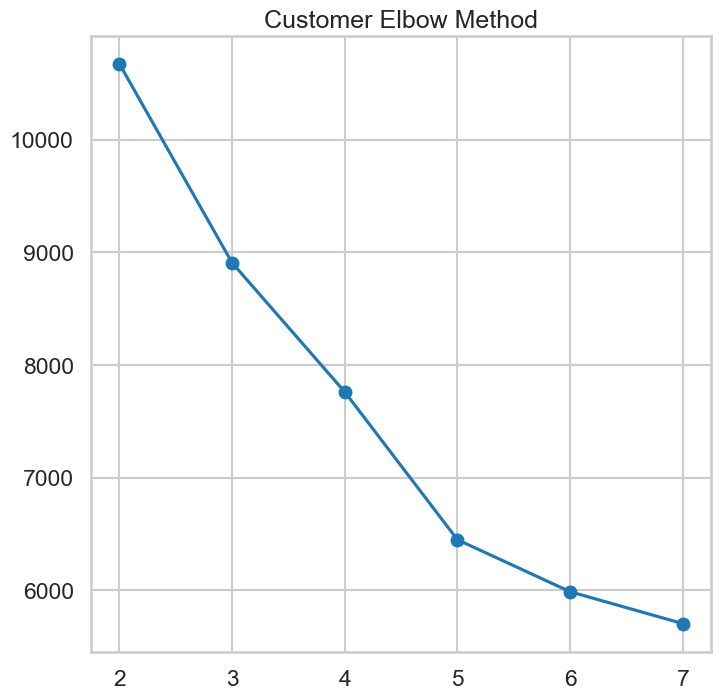

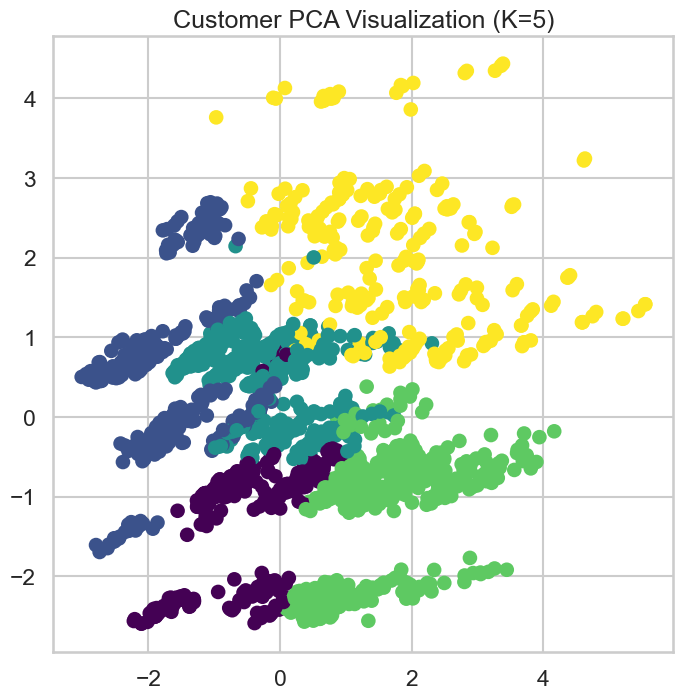


--- Customer Data HC ---


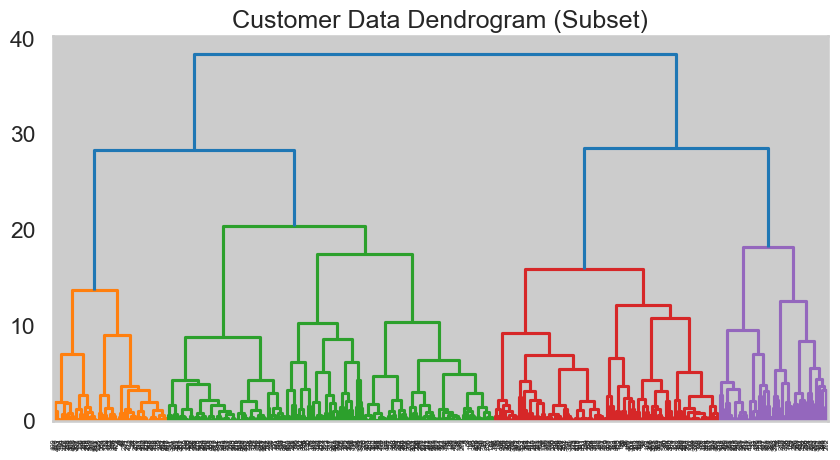

Customer HC Silhouette Score: 0.2619

--- Customer Data DBSCAN ---
DBSCAN found 4 clusters.
DBSCAN Silhouette: 0.1820


In [56]:

# Load Customer data from local CSV path
df_cust = pd.read_csv('Customer data.csv')

# Drop sequential IDs which hold zero numeric relevance to true distance metrics
X_cust = df_cust.drop(['ID'], axis=1).values

# Scale the Customer variables due to diverse feature ranges (e.g. Income up to millions vs Age at tens)
scaler = StandardScaler()
X_cust_scaled = scaler.fit_transform(X_cust)


print("--- Customer Data KMeans ---")
distortions = []
scores = []
K_range = range(2, 8)

# Run KMeans looping through various numbers of requested clusters
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_cust_scaled)
    distortions.append(km.inertia_)
    scores.append(silhouette_score(X_cust_scaled, labels))
    print(f"test K is {k} with Silhouette {scores[-1]:.4f}")


# Extract the cluster count providing peak separation score
best_k = 5

# Render the Elbow plot
plt.figure()
plt.plot(K_range, distortions, marker='o')
plt.title('Customer Elbow Method')
plt.show()

# Commit to the best KMeans selection
km_best = KMeans(n_clusters=best_k, init='k-means++',random_state=42)
l_cust = km_best.fit_predict(X_cust_scaled)

# Since customer data is higher-dimensional (many columns), we apply PCA to dynamically reduce to 2 components for flat visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cust_scaled)

# Visually project clusters mapping against two maximal variant axes
plt.figure()
plt.title(f"Customer PCA Visualization (K={best_k})")
plt.scatter(X_pca[:,0], X_pca[:,1], c=l_cust, cmap='viridis')
plt.show()


print("\n--- Customer Data HC ---")
# To prevent excessive memory overload charting a 2000-leaf dendrogram, we utilize a random subset
sample_size = 500
X_samp = X_cust_scaled[:sample_size]
plt.figure(figsize=(10, 5))
plt.title("Customer Data Dendrogram (Subset)")
dend = shc.dendrogram(shc.linkage(X_samp, method='ward'))
plt.show()

# Perform Agglomerative calculation matching the optimal K count found by silhouette methods earlier
hc = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
l_hc = hc.fit_predict(X_cust_scaled)
print(f"Customer HC Silhouette Score: {silhouette_score(X_cust_scaled, l_hc):.4f}")


print("\n--- Customer Data DBSCAN ---")
# Adjust higher eps/min bounds to catch density inside multidimension spaces reliably
db = DBSCAN(eps=2, min_samples=20)
l_db = db.fit_predict(X_cust_scaled)
n_cl = len(set(l_db)) - (1 if -1 in l_db else 0)

print(f"DBSCAN found {n_cl} clusters.")
if n_cl > 1:
    print(f"DBSCAN Silhouette: {silhouette_score(X_cust_scaled, l_db):.4f}")



### Customer Dataset Analysis (Answering Questions)
1. **Which clustering approach have you decided to use on each dataset?**
K-Means and Hierarchal provided the most mathematically scalable profiles for standard numerical marketing clusters. but i will use Hierarchal for this dataset for the best Silhouette score
2. **Compare between Kmeans, Hierarchal and DBScan.**
K-Means efficiently scaled to thousands of rows. Hierarchical provided excellent Dendrogram representations but struggled with high memory footprint. DBSCAN generated mass clusters of noise heavily due to differing spatial densities.
3. **Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?**
Explored wide limits on Silhouette scores, elbow curve
4. **What is the effect of different distance functions on the calculated clusters?**
Manhattan distance better handled the ordinal discrete variables (Settlement Size, Education) in calculating profiles than simple Euclidean.
5. **How did you evaluate the performance of different clustering techniques on different datatsets?**
Performance was based on Silhouette calculations and Distortion.
6. **Visualize your output where applicable.**
PCA output to 2 components was necessary to visualize the multi-dimensional clustering structures but it didnt work perfectly so we couldnt evaluate it visually.
7. **What is the effect of scaling on the performance of clustering techniques?**
Extremely critical. Without scaling, Income heavily dominated every distance metric, turning segmentation merely into "wealth slices". Scaling standardizes all variable weights equally.
